In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_IG(imbalances):
    return (imbalances[:,:,0] - np.min(imbalances, axis=-1)) / imbalances[:,:,0]

In [3]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

### Lorenz 96, IG vs k both with and without embeddings

In [4]:
epsilons = np.linspace(0.,1.5,31)
ks = np.array([1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 250, 500, 1500])
alphas = np.linspace(0.,0.25,50)

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((len(ks),len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(ks),len(epsilons),len(alphas)))
for i_k, k in enumerate(ks):
    info_imbalances_X_to_Y[i_k], info_imbalances_Y_to_X[i_k] = pickle.load(open(f"./analysis/ig_allcoords/pickles/lorenz96/k{k}.p","rb"))
IGs_X_to_Y = compute_IG(info_imbalances_X_to_Y)
IGs_Y_to_X = compute_IG(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((len(ks),len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((len(ks),len(epsilons),len(alphas))) 
for i_k, k in enumerate(ks):
    info_imbalances_X_to_Y_emb[i_k], info_imbalances_Y_to_X_emb[i_k] = pickle.load(open(f"./analysis/ig_embeddings/pickles/lorenz96/k{k}.p","rb"))
IGs_X_to_Y_emb = compute_IG(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb = compute_IG(info_imbalances_Y_to_X_emb)

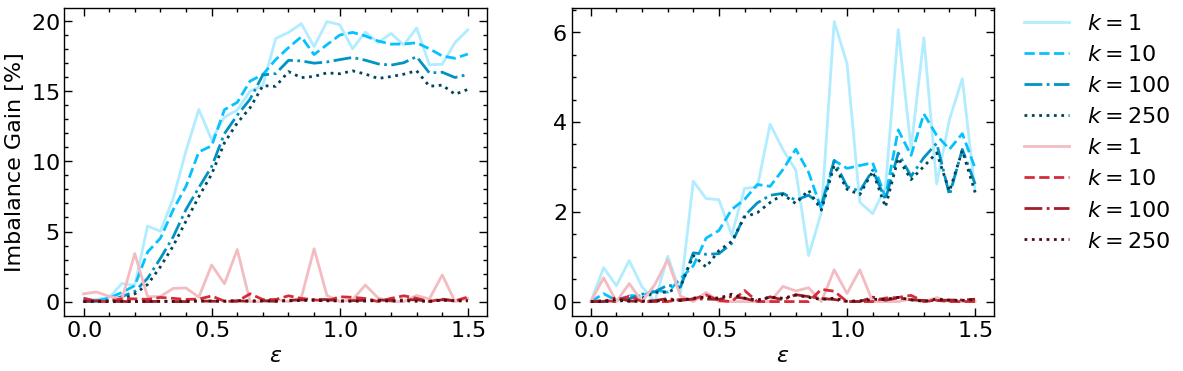

In [5]:
lines = ['-','--','-.',':']
light = [0.3,0.95,1.2,1.6]

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(12,4))

line_n = 0
for i_k, k in enumerate(ks):
        if k in [1, 10, 100, 250]:#, 1500]: #1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200
                ax[0].plot(epsilons, 100*IGs_X_to_Y[i_k], lines[line_n], color=lighten_color(colors[0],light[line_n]))
                ax[1].plot(epsilons, 100*IGs_X_to_Y_emb[i_k], lines[line_n], color=lighten_color(colors[0],light[line_n]), label=f"$k = {k}$")
                line_n += 1

line_n = 0
for i_k, k in enumerate(ks):
        if k in [1, 10, 100, 250]:#, 1500]: #1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200
                ax[0].plot(epsilons, 100*IGs_Y_to_X[i_k], lines[line_n], color=lighten_color(colors[1],light[line_n]))
                ax[1].plot(epsilons, 100*IGs_Y_to_X_emb[i_k], lines[line_n], color=lighten_color(colors[1],light[line_n]), label=f"$k = {k}$")
                line_n += 1

ax[0].set(ylabel="Imbalance Gain [%]", xlabel="$\\epsilon$")
ax[1].set(xlabel="$\\epsilon$")
ax[1].legend(loc=(1.05,.18))

plt.savefig("./figures/IG_vs_epsilon_v3.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

epsilon = 0.75


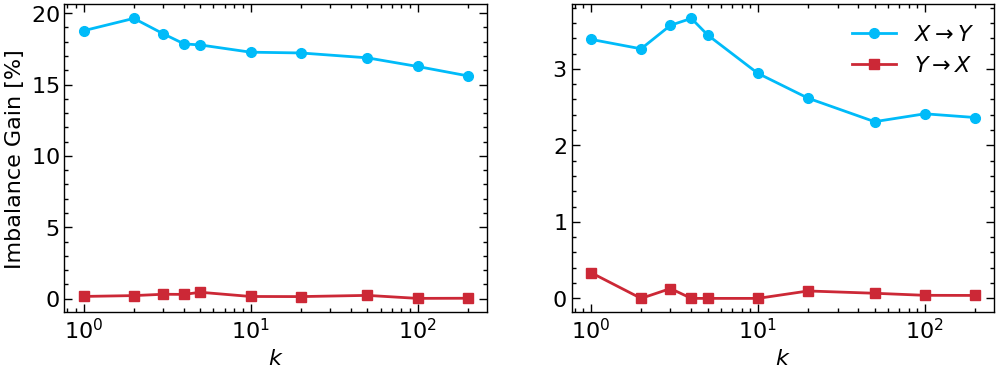

In [6]:
i_eps = 15
print(f"epsilon = {epsilons[i_eps]}")

selected_indices = np.array([0,1,2,3,4,5,7,13,14,15]) ##1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(ks[selected_indices], 100*IGs_X_to_Y[selected_indices,i_eps], 'o-', markersize=7, color=colors[0])
ax[0].plot(ks[selected_indices], 100*IGs_Y_to_X[selected_indices,i_eps], 's-', markersize=7, color=colors[1])
ax[0].set()
ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(ks[selected_indices], 100*IGs_X_to_Y_emb[selected_indices,i_eps], 'o-', markersize=7, color=colors[0], label="$X\\rightarrow Y$")
ax[1].plot(ks[selected_indices], 100*IGs_Y_to_X_emb[selected_indices,i_eps], 's-', markersize=7, color=colors[1], label="$Y\\rightarrow X$")
ax[1].axes.xaxis.set_ticklabels([])

ax[1].legend()
ax[0].set(xscale="log", xlabel="$k$", ylabel="Imbalance Gain [%]")
ax[1].set(xscale="log", xlabel="$k$")

plt.show()